# Introducción a Sistemas de Control: Modelado y Momento de Inercia


- Sistemas de Control
- Prof. Hernán Felipe García PhD
- Ingeniería Electrónica
- Universidad de Antioquia

En el estudio de los sistemas de control, antes de diseñar un controlador, necesitamos un modelo matemático del sistema físico. Para los sistemas mecánicos rotacionales (como motores, brazos robóticos o satélites), el **momento de inercia ($J$)** es una propiedad fundamental que determina cuánta resistencia opone un cuerpo a cambiar su velocidad angular.

## Objetivos de esta clase asíncrona:
1. Recordar la definición matemática del momento de inercia usando cálculo.
2. Utilizar Python (`sympy`) para calcular analíticamente el momento de inercia de geometrías comunes.
3. Conectar esta propiedad física con la ecuación diferencial del sistema y su respuesta dinámica.

In [ ]:
!pip install control

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 578.3/578.3 kB 9.9 MB/s eta 0:00:00


In [ ]:
# Importamos las librerías necesarias
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
import control as ctrl

# Configuramos la impresión de SymPy para que las ecuaciones se vean elegantes
sp.init_printing(use_unicode=True)

## 1. El Momento de Inercia desde el Cálculo

El momento de inercia $J$ respecto a un eje se define como la integral del cuadrado de la distancia $r$ desde el eje de rotación hasta cada elemento de masa $dm$:

$$J = \int r^2 dm$$

Para un cuerpo tridimensional con densidad volumétrica $\rho$, el diferencial de masa es $dm = \rho dV$. Si la densidad es uniforme, podemos sacarla de la integral.



Vamos a calcular el momento de inercia de dos elementos clásicos en ingeniería de control:
1. **Un rotor cilíndrico** (común en motores DC).
2. **Una varilla delgada** pivotada en un extremo (común en péndulos y brazos manipuladores).

In [ ]:
# Definimos los símbolos matemáticos
r, R, L, M, rho, z, theta = sp.symbols('r R L M rho z theta', positive=True)

print("--- 1. Momento de inercia de un Cilindro Sólido (Rotor) ---")
# Volumen del cilindro: V = pi * R^2 * L
# dm = rho * r * dr * d(theta) * dz (en coordenadas cilíndricas)
# Integral triple: J = integral(r^2 * rho * r) dr d(theta) dz

# Planteamos la integral
J_cilindro_int = sp.integrate(rho * r**3, (r, 0, R), (theta, 0, 2*sp.pi), (z, 0, L))

# Sustituimos la densidad rho = M / V = M / (pi * R^2 * L)
rho_cilindro = M / (sp.pi * R**2 * L)
J_cilindro = J_cilindro_int.subs(rho, rho_cilindro).simplify()

display("Inercia del Cilindro (J_c):", J_cilindro)

print("\n--- 2. Momento de inercia de una Varilla pivotada en un extremo ---")
# Densidad lineal lambda_ = M / L
# dm = lambda_ * dx
x = sp.symbols('x', positive=True)

J_varilla_int = sp.integrate((M/L) * x**2, (x, 0, L))
J_varilla = J_varilla_int.simplify()

display("Inercia de la Varilla (J_v):", J_varilla)

--- 1. Momento de inercia de un Cilindro Sólido (Rotor) ---


'Inercia del Cilindro (J_c):'

   2
M⋅R 
────
 2  


--- 2. Momento de inercia de una Varilla pivotada en un extremo ---


'Inercia de la Varilla (J_v):'

 2  
L ⋅M
────
 3  

## 2. Modelado del Sistema de Control

Una vez conocemos $J$, aplicamos la Segunda Ley de Newton para la rotación. Supongamos un motor que aplica un torque $\tau(t)$ a nuestro rotor cilíndrico, el cual experimenta una fricción viscosa $b$. La ecuación diferencial es:

$$J \ddot{\theta}(t) + b \dot{\theta}(t) = \tau(t)$$

Si pasamos al dominio de Laplace para encontrar la **Función de Transferencia** entre la velocidad angular $\Omega(s) = s\Theta(s)$ y el torque de entrada $T(s)$:

$$J s \Omega(s) + b \Omega(s) = T(s)$$
$$G(s) = \frac{\Omega(s)}{T(s)} = \frac{1}{J s + b}$$

Veamos cómo el valor del momento de inercia $J$ (que acabamos de calcular con cálculo integral) afecta la dinámica del sistema frente a un torque constante (respuesta al escalón).

Valor numérico de la Inercia (J): 0.010000000000000002 kg.m^2


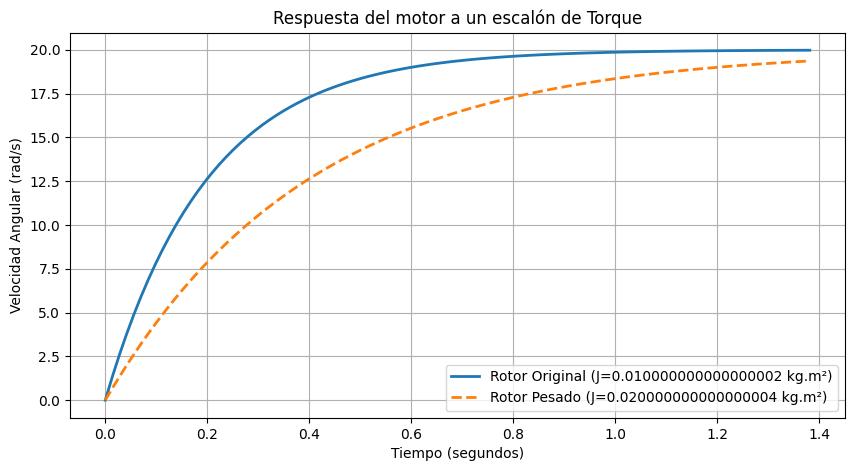

In [ ]:
# Parámetros físicos asumidos para la simulación
masa_rotor = 2.0    # kg
radio_rotor = 0.1   # metros
friccion_b = 0.05   # N.m.s/rad

# 1. Usamos la fórmula hallada simbólicamente para calcular el valor numérico
# J = (1/2) * M * R^2
J_num = 0.5 * masa_rotor * (radio_rotor**2)
print(f"Valor numérico de la Inercia (J): {J_num} kg.m^2")

# 2. Creamos la Función de Transferencia G(s) = 1 / (J*s + b)
numerador = [1]
denominador = [J_num, friccion_b]
sistema_motor = ctrl.TransferFunction(numerador, denominador)

# 3. Simulamos la respuesta al escalón (aplicar un torque constante de 1 N.m)
tiempo, velocidad = ctrl.step_response(sistema_motor)

# Para contrastar, creamos un sistema con el doble de inercia (rotor más pesado o ancho)
sistema_pesado = ctrl.TransferFunction([1], [J_num * 2, friccion_b])
tiempo_p, velocidad_p = ctrl.step_response(sistema_pesado, T=tiempo)

# 4. Graficamos los resultados
plt.figure(figsize=(10, 5))
plt.plot(tiempo, velocidad, label=f'Rotor Original (J={J_num} kg.m²)', linewidth=2)
plt.plot(tiempo_p, velocidad_p, label=f'Rotor Pesado (J={J_num * 2} kg.m²)', linestyle='--', linewidth=2)

plt.title('Respuesta del motor a un escalón de Torque')
plt.xlabel('Tiempo (segundos)')
plt.ylabel('Velocidad Angular (rad/s)')
plt.legend()
plt.grid(True)
plt.show()

## Conclusión de la sesión

Observa la gráfica resultante:
* El sistema con **mayor momento de inercia** tarda más tiempo en alcanzar su velocidad final. Físicamente, "se resiste" más al cambio.
* En Control, esto se traduce en una **constante de tiempo mayor** ($\tau = J/b$), lo que hace al sistema más lento.

Entender de dónde viene $J$ mediante el cálculo nos permite, como ingenieros, tomar decisiones de diseño desde la etapa mecánica antes de siquiera pensar en sintonizar un controlador PID.

## 3. El Teorema de los Ejes Paralelos (Teorema de Steiner)

En el mundo real de la robótica y la automatización, es muy raro que un eslabón o pieza mecánica rote exactamente sobre su centro de masa. Piensa en el brazo de un robot: el motor (y por ende el eje de rotación) se encuentra en un extremo (la articulación), mientras que el centro de masa del eslabón está más hacia el medio.

Para no tener que recalcular la integral desde cero cada vez que el eje de rotación cambia, utilizamos el **Teorema de Steiner**:

$$J_{eje} = J_{cm} + M d^2$$

Donde:
* $J_{eje}$ es el momento de inercia alrededor del nuevo eje de rotación.
* $J_{cm}$ es el momento de inercia alrededor del centro de masa.
* $M$ es la masa total del cuerpo.
* $d$ es la distancia perpendicular entre el nuevo eje y el centro de masa.



Vamos a demostrar con Python que calcular la inercia de una varilla desde su centro y luego aplicar Steiner, nos da exactamente el mismo resultado que la integral de la varilla pivotada en el extremo que hicimos en la sección 1.

In [ ]:
print("--- 3. Comprobación del Teorema de Steiner ---")

# 1. Calculamos J_cm de una varilla rotando sobre su centro (de -L/2 a L/2)
# Densidad lineal lambda_ = M / L
J_cm_int = sp.integrate((M/L) * x**2, (x, -L/2, L/2))
J_cm = J_cm_int.simplify()

display("Inercia en el Centro de Masa (J_cm):", J_cm)

# 2. Aplicamos el Teorema de Steiner para mover el eje al extremo
# La distancia del centro al extremo es d = L / 2
d = L / 2
J_steiner = J_cm + M * d**2
J_steiner = J_steiner.simplify()

display("Inercia en el extremo usando Steiner (J_eje):", J_steiner)

# 3. Comparamos con el resultado de la integral directa (J_varilla de la Celda 4)
print("\n¿Es igual el resultado de Steiner al de la integral directa que hicimos antes?")
if J_steiner == J_varilla:
    print("¡Sí! Ambos métodos arrojan exactamente la misma ecuación matemática.")
else:
    print("No, hay una diferencia en los cálculos.")

--- 3. Comprobación del Teorema de Steiner ---


'Inercia en el Centro de Masa (J_cm):'

 2  
L ⋅M
────
 12 

'Inercia en el extremo usando Steiner (J_eje):'

 2  
L ⋅M
────
 3  


¿Es igual el resultado de Steiner al de la integral directa que hicimos antes?
¡Sí! Ambos métodos arrojan exactamente la misma ecuación matemática.


## Reflexión para el Diseño de Control

Noten que la inercia en el extremo ($ML^2/3$) es cuatro veces mayor que la inercia en el centro de masa ($ML^2/12$).

**¿Qué significa esto para tu sistema de control?**
Si diseñas un brazo robótico y colocas cargas pesadas lejos del eje de rotación (aumentando la distancia $d$), el momento de inercia $J$ del sistema crecerá de forma cuadrática ($d^2$). Esto obligará al motor de la articulación a realizar un esfuerzo (torque) inmensamente mayor para lograr la misma aceleración angular, saturando los actuadores y haciendo que tu controlador PID tarde más en estabilizar el sistema.

El diseño mecánico y el control dinámico están íntimamente ligados.

## 4. Reto Práctico: Diseño de la Rueda para un Robot Móvil

En la robótica móvil, el diseño de las ruedas o los eslabones afecta directamente la agilidad del sistema y el consumo de energía. Supongamos que estás diseñando una rueda para un robot y decides ahuecarla para ahorrar material, convirtiéndola en un **cilindro hueco** (un disco con un agujero central).

**Tu misión:**
1. **Cálculo Simbólico:** Utiliza `sympy` para calcular el momento de inercia de un cilindro hueco de masa $M$, longitud $L$, radio interno $R_1$ y radio externo $R_2$.
   *(Pista: La integral es igual a la del cilindro sólido, pero los límites de integración para el radio $r$ van desde $R_1$ hasta $R_2$. Recuerda actualizar la fórmula del volumen para la densidad $\rho$).*
2. **Modelado Dinámico:** Usando la librería `control`, crea la función de transferencia para esta nueva rueda hueca.
3. **Simulación:** Grafica la respuesta al escalón y compárala con la de un cilindro sólido de la misma masa y radio exterior.

**Pregunta de análisis para el entregable:** ¿Qué rueda hace que el sistema responda más rápido y por qué?




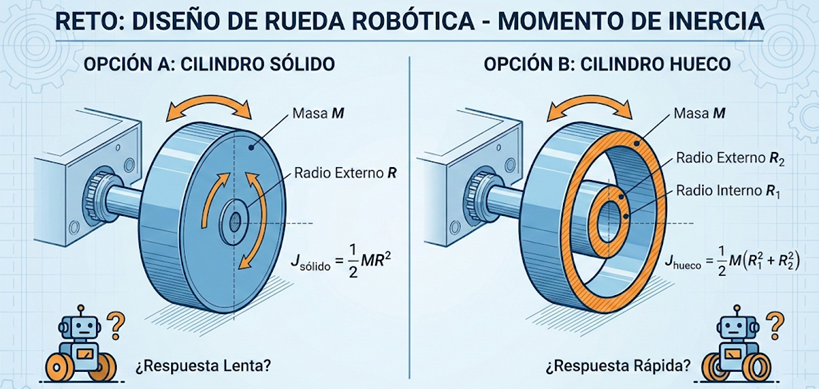

¿Cual maximiza la agilidad del control?

Ahora calcula $J$ con _sympy_ y simula la dinámica.

'Inercia del Cilindro (J_c):'

  ⎛  2     2⎞
M⋅⎝R₁  + R₂ ⎠
─────────────
      2      

Valor numérico de la Inercia (J): 0.0164 kg.m^2


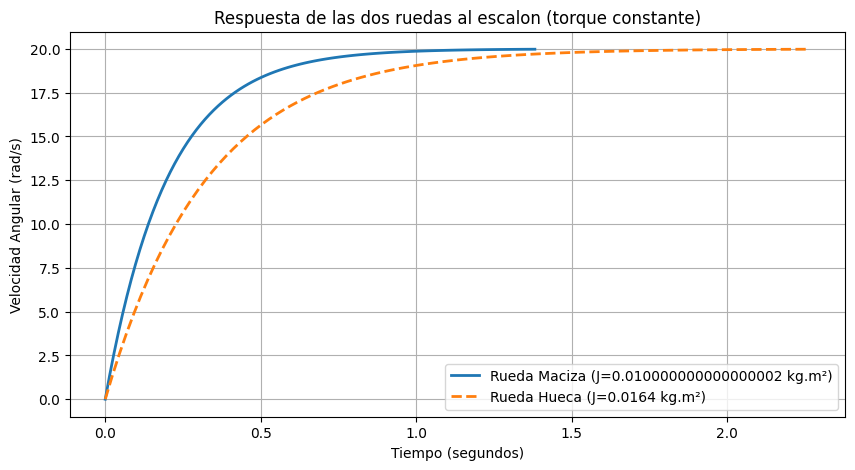

In [ ]:
# ==========================================
# RETO: INERCIA DE UN CILINDRO HUECO
# ==========================================

# 1. Definición de nuevos símbolos
R1, R2 = sp.symbols('R1 R2', positive=True)

# 2. Plantea la integral triple para el cilindro hueco
# J_hueco_int = sp.integrate( ... )
# TU CÓDIGO AQUÍ:
J_cilindro_int_hueco = sp.integrate(rho * r**3, (r, R1, R2), (theta, 0, 2*sp.pi), (z, 0, L))
# 3. Sustituye la densidad (rho) por Masa / Volumen_hueco
# Volumen_hueco = pi * (R2**2 - R1**2) * L
# TU CÓDIGO AQUÍ:
rho_cilindro_hueco = M / (sp.pi * (R2**2 - R1**2) * L)
J_cilindro_hueco = J_cilindro_int_hueco.subs(rho, rho_cilindro_hueco).simplify()

display("Inercia del Cilindro (J_c):", J_cilindro_hueco)


# ==========================================
# SIMULACIÓN DE CONTROL
# ==========================================
# Asume los siguientes valores:
# Masa (M) = 2.0 kg
# Radio externo (R2) = 0.1 m
# Radio interno (R1) = 0.08 m
# Fricción (b) = 0.05

# 4. Calcula el valor numérico de la inercia del cilindro hueco
# TU CÓDIGO AQUÍ:

masa_hueco = 2.0    # kg
radio_interno = 0.08   # metros
radio_externo = 0.1   # metros
friccion_b = 0.05   # N.m.s/rad

J_num_hueco = 0.5 * masa_hueco * (radio_interno**2 + radio_externo**2)
print(f"Valor numérico de la Inercia (J): {J_num_hueco} kg.m^2")

# 5. Crea la función de transferencia y simula el paso (step_response)
# TU CÓDIGO AQUÍ:
numerador = [1]
denominador_hueco = [J_num_hueco, friccion_b]
sistema_rueda = ctrl.TransferFunction(numerador, denominador_hueco)

tiempo_hueco, velocidad_hueco = ctrl.step_response(sistema_rueda)

# 6. Grafica y compara con el sistema_motor de la Celda 6
# TU CÓDIGO AQUÍ:

plt.figure(figsize=(10, 5))
plt.plot(tiempo, velocidad, label=f'Rueda Maciza (J={J_num} kg.m²)', linewidth=2)
plt.plot(tiempo_hueco, velocidad_hueco, label=f'Rueda Hueca (J={J_num_hueco} kg.m²)', linestyle='--', linewidth=2)

plt.title('Respuesta de las dos ruedas al escalon (torque constante)')
plt.xlabel('Tiempo (segundos)')
plt.ylabel('Velocidad Angular (rad/s)')
plt.legend()
plt.grid(True)
plt.show()

La constante de tiempo de un sistema rotacional depende del momento de inercia
𝐽. En un cilindro sólido, la masa está más cerca del eje, lo que reduce 𝐽 y hace que la constante de tiempo
𝜏 = 𝐽/𝑏 sea menor. Esto significa que el sistema responde más rápido a un torque constante, alcanzando su velocidad final en menos tiempo. En cambio, en un cilindro hueco la masa se concentra en el borde, aumentando
𝐽
 y con ello la constante de tiempo, lo que ralentiza la respuesta del sistema.

Una forma sencilla para entenderlo es un experimento que relicé con mi compañero, lo llamamos el experimento de la silla giratoria: cuando mi compañero tenía los pies recogidos, la masa estaba más cerca del eje y girarlo fue fácil; pero al estirar los pies, la masa se alejó del eje, el momento de inercia aumentó y girarlo se volvió más difícil. Esa misma diferencia explica por qué una rueda maciza responde más rápido que una hueca bajo el mismo torque.

# Estudiantes

- Juan Pablo González Blandón
- Esteban Escamilla Gomez


### 📝 Instrucciones de entrega
Una vez hayas completado la celda de código anterior y la gráfica se genere correctamente:
1. Añade una celda de texto (Markdown) debajo de la gráfica.
2. Escribe una breve conclusión (máximo 2 párrafos) respondiendo a la pregunta de análisis: **¿Cómo afecta la distribución de la masa (cilindro sólido vs. hueco) a la constante de tiempo del sistema de control?**
3. Guarda tu Notebook (`.ipynb`) y súbelo a la plataforma del curso.

¡Muchos éxitos y nos vemos en la próxima clase sincrónica para empezar a diseñar controladores PID sobre estos modelos!